### Sklearn Refresher

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [13]:
# Get data 
df = pd.read_csv('data/IMDB Dataset.csv')

# Preprocessing
df_small = df.sample(n=4000, random_state=42).copy()

df_small['sentiment'] = df_small['sentiment'].map({'positive': 1, 'negative': -1})

vectorizer = TfidfVectorizer(stop_words='english', max_features=2500)
X_imdb = vectorizer.fit_transform(df_small['review'])
y_imdb = df_small['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(X_imdb, y_imdb, test_size=0.5, random_state=42)

In [4]:
# KNN classification
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier() 
knn.fit(X_train, y_train)

prediction_0 = knn.predict(X_test)[0]
print(f"Prediction for the first review in the test set: {prediction_0}")

Prediction for the first review in the test set: -1


In [6]:
# Test with different values of k
k_values = range(1, 11)
accuracies = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracy = knn.score(X_test, y_test)
    accuracies[k] = accuracy

print("Accuracies for different values of k:")
for k, accuracy in accuracies.items():
    print(f"k={k}: accuracy={accuracy:.4f}")

Accuracies for different values of k:
k=1: accuracy=0.6245
k=2: accuracy=0.6015
k=3: accuracy=0.6570
k=4: accuracy=0.6260
k=5: accuracy=0.6630
k=6: accuracy=0.6410
k=7: accuracy=0.6650
k=8: accuracy=0.6420
k=9: accuracy=0.6650
k=10: accuracy=0.6555


### Logistic Regression and SVM

In [10]:
from sklearn import datasets
from sklearn.linear_model import LogisticRegression

digits = datasets.load_digits()
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=42)

In [11]:
# Apply logistic regression to the digits dataset
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print(f"Logistic Regression accuracy on training data: {lr.score(X_train, y_train):.4f}")
print(f"Logistic Regression accuracy on test data: {lr.score(X_test, y_test):.4f}")

Logistic Regression accuracy on training data: 1.0000
Logistic Regression accuracy on test data: 0.9733


In [12]:
# Apply SVM to the digits dataset
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)
print(f"SVM accuracy on training data: {svm.score(X_train, y_train):.4f}")
print(f"SVM accuracy on test data: {svm.score(X_test, y_test):.4f}")

SVM accuracy on training data: 0.9963
SVM accuracy on test data: 0.9867


In [ ]:
# SVM is a powerful algorithm for classification tasks, especially when the data is not linearly separable. 
# It works by finding the optimal hyperplane that separates the classes in the feature space. 
# The SVM can also use different kernel functions to handle non-linear relationships in the data.

In [15]:
# Sentiment analysis for movie reviews
lr = LogisticRegression(max_iter=1000)
lr.fit(X_imdb, y_imdb)

review1 = "This movie was fantastic! The acting was great, and the plot was very engaging."
review1_features = vectorizer.transform([review1])

review2 = "Total junk! I'll never watch a film by that director again, no matter how good the reviews are."
review2_features = vectorizer.transform([review2])

print("Review 1:", review1)
print("Probability of being positive:", lr.predict_proba(vectorizer.transform([review1]))[0][1])

print("Review 2:", review2)
print("Probability of being positive:", lr.predict_proba(vectorizer.transform([review2]))[0][1])

Review 1: This movie was fantastic! The acting was great, and the plot was very engaging.
Probability of being positive: 0.7523912083688866
Review 2: Total junk! I'll never watch a film by that director again, no matter how good the reviews are.
Probability of being positive: 0.5182208872005117


### Visualizing Decision Boundaries

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC

In [19]:
# Get wine dataset
wine = datasets.load_wine()
X = wine.data
y = wine.target

In [22]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

def plot_4_classifiers(X, y, classifiers):
    titles = [
        "Logistic Regression",
        "Linear SVC",
        "SVC (RBF Kernel)",
        "K-Nearest Neighbors"
    ]

    fig, sub = plt.subplots(2, 2, figsize=(10, 10))
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    for clf, title, ax in zip(classifiers, titles, sub.flatten()):
        DecisionBoundaryDisplay.from_estimator(
            clf,
            X,
            response_method="predict",
            cmap=plt.cm.coolwarm,
            alpha=0.8,
            ax=ax
        )

        ax.scatter(
            X[:, 0], 
            X[:, 1], 
            c=y, 
            cmap=plt.cm.coolwarm, 
            edgecolors="k", 
            s=25
        )

        ax.set_xticks(())
        ax.set_yticks(())
        ax.set_title(title)

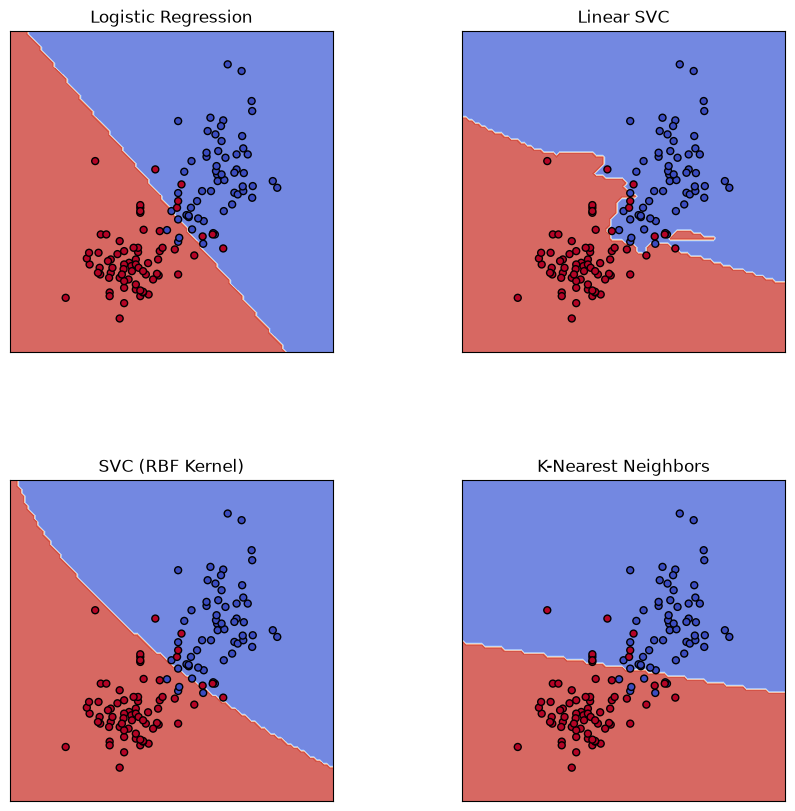

In [29]:
from sklearn.datasets import load_wine

wine = load_wine()
X_full = wine.data
y_full = wine.target

binary_mask = (y_full == 0) | (y_full == 1)
X_binary = X_full[binary_mask]
y_binary = y_full[binary_mask]

X = X_binary[:, [0, 9]]
y = y_binary

classifiers = [LogisticRegression(max_iter=10000), KNeighborsClassifier(), SVC(), LinearSVC(max_iter=10000)]
for clf in classifiers:
    clf.fit(X, y)
    
for c in classifiers:
    c.fit(X, y)
    
plot_4_classifiers(X, y, classifiers)
plt.show()


### Loss Functions

In [32]:
import numpy as np
X = np.array([[ 1.78862847,  0.43650985], [ 0.09649747, -1.8634927 ], [-0.2773882 , -0.35475898], [-3.08274148,  2.37299932], [-3.04381817,  2.52278197], [-1.31386475,  0.88462238], [-2.11868196,  4.70957306], [-2.94996636,  2.59532259], [-3.54535995,  1.45352268], [ 0.98236743, -1.10106763], [-1.18504653, -0.2056499 ], [-1.51385164,  3.23671627], [-4.02378514,  2.2870068 ], [ 0.62524497, -0.16051336], [-3.76883635,  2.76996928], [ 0.74505627,  1.97611078], [-1.24412333, -0.62641691], [-0.80376609, -2.41908317], [-0.92379202, -1.02387576], [ 1.12397796, -0.13191423]])
y = np.array([-1, -1, -1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1, -1, -1, -1, -1, -1])

In [33]:
# from DataCamp
def plot_classifier(X, y, clf, ax=None, ticks=False, proba=False, lims=None): # assumes classifier "clf" is already fit
    X0, X1 = X[:, 0], X[:, 1]
    xx, yy = make_meshgrid(X0, X1, lims=lims)

    if ax is None:
        plt.figure()
        ax = plt.gca()
        show = True
    else:
        show = False

    # can abstract some of this into a higher-level function for learners to call
    cs = plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8, proba=proba)
    if proba:
        cbar = plt.colorbar(cs)
        cbar.ax.set_ylabel('probability of red $\Delta$ class', fontsize=20, rotation=270, labelpad=30)
        cbar.ax.tick_params(labelsize=14)
    #ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=30, edgecolors='k', linewidth=1)
    labels = np.unique(y)
    if len(labels) == 2:
        ax.scatter(X0[y==labels[0]], X1[y==labels[0]], cmap=plt.cm.coolwarm, s=60, c='b', marker='o', edgecolors='k')
        ax.scatter(X0[y==labels[1]], X1[y==labels[1]], cmap=plt.cm.coolwarm, s=60, c='r', marker='^', edgecolors='k')
    else:
        ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k', linewidth=1)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
#     ax.set_xlabel(data.feature_names[0])
#     ax.set_ylabel(data.feature_names[1])
    if ticks:
        ax.set_xticks(())
        ax.set_yticks(())
#     ax.set_title(title)
    if show:
        plt.show()
    else:
        return ax

def make_meshgrid(x, y, h=.02, lims=None):
    if lims is None:
        x_min, x_max = x.min() - 1, x.max() + 1
        y_min, y_max = y.min() - 1, y.max() + 1
    else:
        x_min, x_max, y_min, y_max = lims
        
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, proba=False, **params):
    if proba:
        Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    else:
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        
    Z = Z.reshape(xx.shape)
    
    out = ax.contourf(xx, yy, Z, **params)
    return out

<>:17: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:17: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_19165/4250987140.py:17: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  cbar.ax.set_ylabel('probability of red $\Delta$ class', fontsize=20, rotation=270, labelpad=30)


/tmp/ipykernel_19165/4250987140.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[0]], X1[y==labels[0]], cmap=plt.cm.coolwarm, s=60, c='b', marker='o', edgecolors='k')
/tmp/ipykernel_19165/4250987140.py:23: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[1]], X1[y==labels[1]], cmap=plt.cm.coolwarm, s=60, c='r', marker='^', edgecolors='k')


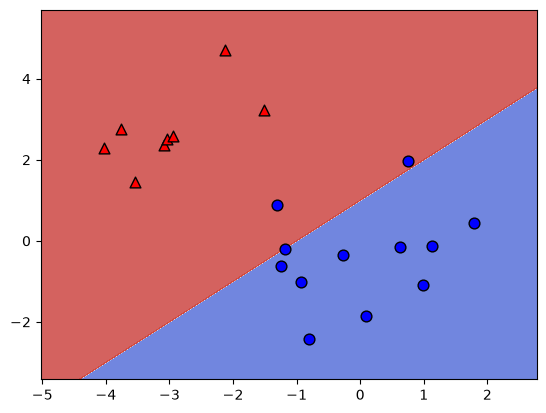

Number of errors: 2


In [41]:
# Simulate a model
model = LogisticRegression()
model.fit(X, y)  # Fit the model to the data

# Set model coefficients and intercept
model.coef_ = np.array([[-1.0, 1.0]])
model.intercept_ = np.array([-1])

plot_classifier(X, y, model)

# Print number of errors
num_errors = np.sum(model.predict(X) != y)
print(f"Number of errors: {num_errors}")

/tmp/ipykernel_19165/4250987140.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[0]], X1[y==labels[0]], cmap=plt.cm.coolwarm, s=60, c='b', marker='o', edgecolors='k')
/tmp/ipykernel_19165/4250987140.py:23: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[1]], X1[y==labels[1]], cmap=plt.cm.coolwarm, s=60, c='r', marker='^', edgecolors='k')


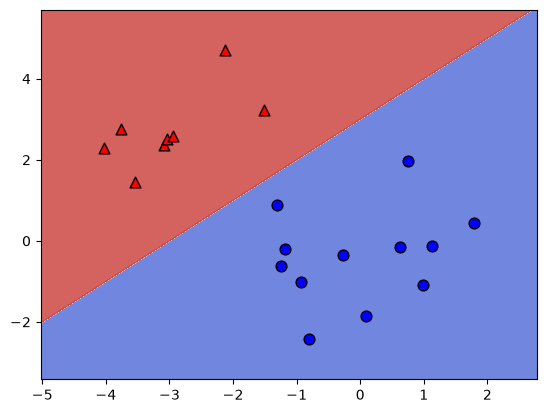

Number of errors: 0


In [42]:
# Change model coefficients and intercept
model.coef_ = np.array([[-1.0, 1.0]])
model.intercept_ = np.array([-3])

plot_classifier(X, y, model)

# Print number of errors
num_errors = np.sum(model.predict(X) != y)
print(f"Number of errors: {num_errors}")

#### Minimizing a loss function

In [43]:
# Squared error
def my_loss(w):
    s = 0
    for i in range(y.size):
        y_i_true = y[i]
        y_i_pred = np.dot(w, X[i])
        s += (y_i_true - y_i_pred) ** 2
    return s

In [45]:
from scipy.optimize import minimize
w_fit = minimize(my_loss, X[0]).x
print(f"Fitted weights: {w_fit}")

Fitted weights: [-0.10279794  0.24559517]


In [47]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression(fit_intercept=False).fit(X, y)
print(f"Linear Regression coefficients: {lr.coef_}")

Linear Regression coefficients: [-0.10279791  0.2455952 ]


### Lost Function Diagrams

In [48]:
# Mathematical functions for logistic and hinge losses
def logistic_loss(raw_model_output):
    return np.log(1 + np.exp(-raw_model_output))

def hinge_loss(raw_model_output):
    return np.maximum(0, 1 - raw_model_output)

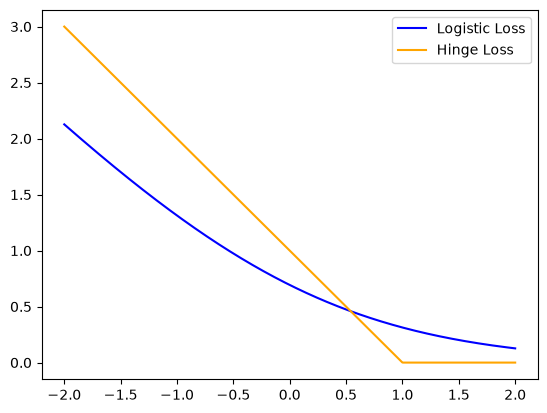

In [49]:
# Create a grid of values and plot
grid = np.linspace(-2, 2, 1000)

plt.plot(grid, logistic_loss(grid), label='Logistic Loss', color='blue')
plt.plot(grid, hinge_loss(grid), label='Hinge Loss', color='orange')
plt.legend()
plt.show()

### Logistic Regression

In [50]:
from sklearn import datasets
from sklearn.linear_model import LogisticRegression

digits = datasets.load_digits()
# Split the dataset into training, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=42)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

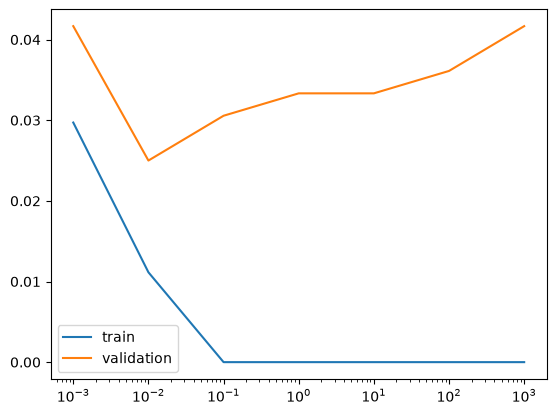

In [53]:
# Regularized Logistic Regression
train_errors = list()
valid_errors = list()

# Loop over different values of C (inverse of regularization strength)
for C in [0.001, 0.01, 0.1, 1, 10, 100, 1000]:
    lr = LogisticRegression(C=C, max_iter=1000)
    lr.fit(X_train, y_train)
    
    train_errors.append(1 - lr.score(X_train, y_train))
    valid_errors.append(1 - lr.score(X_valid, y_valid))

# Plot training and validation errors
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
plt.semilogx(C_values, train_errors, C_values, valid_errors)
plt.legend(("train", "validation"))
plt.show()

In [57]:
# Feature selection with L1 regularization
from sklearn.model_selection import GridSearchCV
lr = LogisticRegression(l1_ratio = 1, solver='liblinear', max_iter=10000)

searcher = GridSearchCV(lr, param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}, cv=5)
searcher.fit(X_imdb, y_imdb)

print(f"Best C: {searcher.best_params_['C']}")

best_lr = searcher.best_estimator_
coefs = best_lr.coef_
print(f"Number of non-zero coefficients: {np.sum(coefs != 0)}")
print(f"Number of zero coefficients: {np.sum(coefs == 0)}")

Best C: 1
Number of non-zero coefficients: 245
Number of zero coefficients: 2255


In [62]:
# identifying most positive and negative words
vocab = vectorizer.get_feature_names_out()

inds_ascending = np.argsort(best_lr.coef_.flatten())
inds_descending = inds_ascending[::-1]

# Print most positive and negative words
print("Most positive words:")
for i in inds_descending[:10]:
    print(f"{vocab[i]}: {best_lr.coef_.flatten()[i]:.4f}")
    
print("\nMost negative words:")
for i in inds_ascending[:10]:
    print(f"{vocab[i]}: {best_lr.coef_.flatten()[i]:.4f}")


Most positive words:
excellent: 8.5453
best: 7.5600
amazing: 7.3422
great: 6.4109
favorite: 6.3690
perfect: 5.9202
enjoyed: 5.0277
fun: 4.6341
today: 3.7794
wonderful: 3.7353

Most negative words:
worst: -14.3330
waste: -11.4124
bad: -9.7379
awful: -9.3973
horrible: -7.8703
stupid: -6.2400
poor: -6.1747
boring: -5.5626
terrible: -5.0685
worse: -5.0431


### Logistic Regression and Probabilities

In [63]:
X = np.array([[ 1.78862847,  0.43650985], [ 0.09649747, -1.8634927 ], [-0.2773882 , -0.35475898], [-3.08274148,  2.37299932], [-3.04381817,  2.52278197], [-1.31386475,  0.88462238], [-2.11868196,  4.70957306], [-2.94996636,  2.59532259], [-3.54535995,  1.45352268], [ 0.98236743, -1.10106763], [-1.18504653, -0.2056499 ], [-1.51385164,  3.23671627], [-4.02378514,  2.2870068 ], [ 0.62524497, -0.16051336], [-3.76883635,  2.76996928], [ 0.74505627,  1.97611078], [-1.24412333, -0.62641691], [-0.80376609, -2.41908317], [-0.92379202, -1.02387576], [ 1.12397796, -0.13191423]])
y = np.array([-1, -1, -1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1, -1, -1, -1, -1, -1])

/tmp/ipykernel_19165/4250987140.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[0]], X1[y==labels[0]], cmap=plt.cm.coolwarm, s=60, c='b', marker='o', edgecolors='k')
/tmp/ipykernel_19165/4250987140.py:23: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[1]], X1[y==labels[1]], cmap=plt.cm.coolwarm, s=60, c='r', marker='^', edgecolors='k')


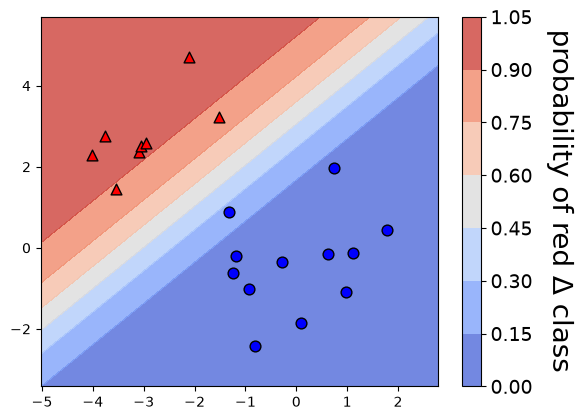

Maximum predicted probability: 0.9973152198521483


In [66]:
model = LogisticRegression(C = 1)

model.fit(X, y)
plot_classifier(X, y, model, proba=True)

prob = model.predict_proba(X)
print(f"Maximum predicted probability:", prob.max())

/tmp/ipykernel_19165/4250987140.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[0]], X1[y==labels[0]], cmap=plt.cm.coolwarm, s=60, c='b', marker='o', edgecolors='k')
/tmp/ipykernel_19165/4250987140.py:23: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[1]], X1[y==labels[1]], cmap=plt.cm.coolwarm, s=60, c='r', marker='^', edgecolors='k')


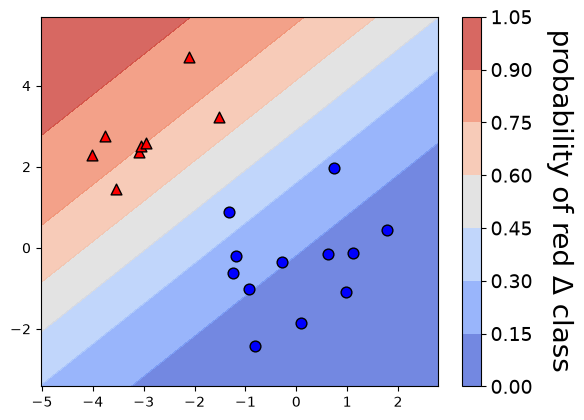

Maximum predicted probability: 0.9351932153846491


In [67]:
model = LogisticRegression(C = 0.1)

model.fit(X, y)
plot_classifier(X, y, model, proba=True)

prob = model.predict_proba(X)
print(f"Maximum predicted probability:", prob.max())

In [68]:
# Visualizing easy and difficult examples

from sklearn import datasets
from sklearn.linear_model import LogisticRegression

digits = datasets.load_digits()
X = digits.data
y = digits.target

In [72]:
def show_digit(i, lr=None):
    plt.imshow(np.reshape(X[i], (8,8)), cmap='gray', vmin = 0, vmax = 16, interpolation=None)
    plt.xticks(())
    plt.yticks(())
    if lr is None:
        plt.title("class label = %d" % y[i])
    else:
        pred = lr.predict(X[i][None])[0]
        pred_prob = lr.predict_proba(X[i][None])[0,pred]
        plt.title("label=%d, prediction=%d, proba=%.2f" % (y[i], pred, pred_prob))
    plt.show()

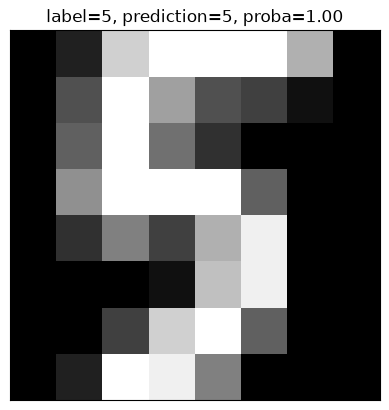

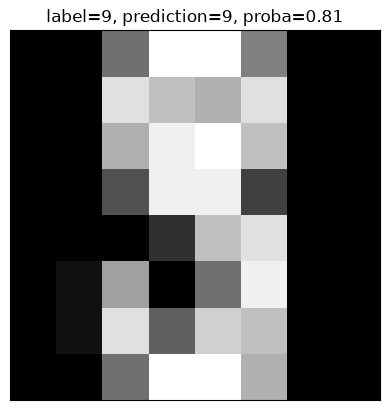

In [73]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)

proba = lr.predict_proba(X)
proba_inds = np.argsort(np.max(proba, axis=1))

# Show the most confident predictions
show_digit(proba_inds[-1], lr)

# Show the least confident predictions
show_digit(proba_inds[0], lr)

### Multi-class Logistic Regression

In [92]:
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=42)

In [94]:
# Fit one vs rest logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

lr_ovr = OneVsRestClassifier(LogisticRegression(max_iter=10000, C = 100))
lr_ovr.fit(X_train, y_train)

print(f"One-vs-rest Logistic Regression accuracy on training data: {lr_ovr.score(X_train, y_train):.4f}")
print(f"One-vs-rest Logistic Regression accuracy on test data: {lr_ovr.score(X_test, y_test):.4f}")

# Fit softmax logistic regression (automatically handles multi-class classification)
lr_softmax = LogisticRegression(max_iter=10000, C = 100)
lr_softmax.fit(X_train, y_train)

print(f"Softmax Logistic Regression accuracy on training data: {lr_softmax.score(X_train, y_train):.4f}")
print(f"Softmax Logistic Regression accuracy on test data: {lr_softmax.score(X_test, y_test):.4f}")

One-vs-rest Logistic Regression accuracy on training data: 0.9993
One-vs-rest Logistic Regression accuracy on test data: 0.9600
Softmax Logistic Regression accuracy on training data: 1.0000
Softmax Logistic Regression accuracy on test data: 0.9644


In [95]:
X_train = np.array([[-2.83895657e-01, -9.51457706e-01], [ 5.33624372e-01,  1.23918071e+00], [-1.17337815e+00, -1.21258188e-01], [-1.19338379e+00,  7.97747166e-01], [-3.74902201e-01, -3.99647889e-01], [-1.11678880e+00, -3.63057976e-01], [ 3.92567929e-02, -1.03949311e+00], [-4.60496902e-01,  7.92206150e-01], [ 3.73372234e-01,  4.49455588e-01], [-5.68303256e-01, -1.12326024e+00], [-8.10825377e-01, -6.71197010e-01], [-2.23456895e-01,  5.01300063e-01], [ 3.31395128e-01, -8.81087488e-01], [ 1.23187925e+00,  6.36307263e-01], [-1.19438566e-01, -1.70031450e+00], [-3.56432381e-01,  8.17597947e-01], [ 3.68396844e-01, -4.89405078e-01], [-2.55373639e-01, -4.18075333e-01], [-1.32645347e+00,  1.04344987e+00], [-5.92850474e-01, -8.01421997e-01], [ 7.27961902e-01, -1.12489821e+00], [-2.13511481e+00,  1.53256634e+00], [ 2.30542073e-01, -8.68803803e-01], [ 1.09813977e+00,  5.83409537e-01], [ 8.38336530e-01,  6.17109567e-01], [ 4.86438237e-01,  3.06669383e-01], [ 7.86915440e-01,  4.44667097e-01], [-4.78932579e-01, -5.66539851e-01], [-2.03300554e-01,  9.36879327e-01], [ 3.39165831e-01,  8.12534012e-01], [-3.61733276e-01,  3.63540549e-01], [ 1.18603363e+00, -2.01359716e+00], [-4.87253757e-01, -6.37446081e-01], [-1.88698497e-01, -5.82874621e-01], [ 9.81411621e-01,  1.33941738e+00], [ 1.50189299e+00,  1.03081206e+00], [-6.44426536e-02, -3.81126339e-01], [ 1.28839740e+00,  1.54321683e+00], [-9.02379254e-01,  2.12912925e-01], [-2.75943790e-01,  6.62190410e-01], [ 1.85875489e-04, -2.22687852e+00], [-1.36218486e-01, -6.12143582e-01], [-8.01189309e-01, -7.31571602e-01], [-1.31114360e+00, -1.11160107e-01], [-1.82715882e-01,  3.45742341e-01], [ 1.62577984e+00,  9.82365559e-02], [ 1.18754221e+00, -9.88047256e-01], [ 3.30896348e-01,  1.74147081e+00], [ 1.06319463e+00,  7.25707477e-01], [-6.31172777e-02,  5.03138338e-01], [ 3.70221639e-01,  1.27315366e+00], [-3.14443989e-03, -2.64384583e-01], [ 3.57484301e-01, -2.27657772e-02], [-7.10889392e-01,  1.54688358e+00], [ 7.62329973e-01,  1.33254405e+00], [-1.55233553e+00, -1.52337441e+00], [-1.00339689e+00,  2.11862140e+00], [ 7.22823193e-01,  3.35405706e-01], [ 9.12755253e-02, -5.04468641e-01], [ 4.95114934e-02, -2.44690106e-01], [-1.40309968e+00, -5.12395416e-01], [-7.75501690e-01, -6.02394114e-01], [ 1.24435378e+00,  1.05314888e+00], [-2.23130848e-02,  1.87403279e+00], [-2.22779816e+00,  1.27046867e+00], [ 4.42928990e-02,  5.97549446e-01], [ 1.14098613e+00,  8.51490630e-01], [ 1.44165046e+00, -8.66600209e-01], [ 1.32295140e-01,  1.62653413e+00], [ 3.69308441e-02,  1.67786453e+00], [-6.12975983e-01, -1.35405850e+00], [ 8.22080441e-01, -7.45448227e-01], [-1.03015455e+00,  1.57828451e+00], [-1.27392825e+00, -1.19848757e-01], [-4.22882508e-01, -3.05961769e-01], [ 1.05127378e+00, -2.29052289e+00], [-7.89554501e-01,  8.57037168e-04], [ 3.73018740e-01, -4.98468373e-01], [-7.21550677e-01, -5.22821271e-01], [ 1.91021707e+00, -1.52700869e+00], [ 6.18671454e-01,  5.31270233e-01], [-1.12104559e+00,  2.87688027e+00], [ 1.21061741e+00, -5.48616370e-01], [-1.25680616e+00, -6.13281706e-02], [-1.50756706e+00,  4.18340765e-01], [ 7.11133123e-01, -7.15113895e-01], [-4.22620092e-01,  5.79287166e-01], [-9.34751978e-01,  3.60387487e-02], [ 1.21135650e+00, -5.78726752e-01], [-1.15320171e+00, -4.85969087e-02], [ 2.62171741e+00,  7.01010427e-01], [-1.48673284e-02, -9.33967286e-01], [-4.71193685e-01,  1.48297028e-01], [ 2.19748594e+00,  8.18579786e-02], [ 8.95326539e-01, -8.20358903e-01], [-6.17111080e-01,  1.27571264e+00], [ 1.09948335e+00, -1.26033634e+00], [-2.59602194e-01,  7.62758510e-01], [ 8.26861357e-01, -8.98524452e-01], [ 1.17328060e+00, -2.02972829e-01], [ 9.44652675e-02,  1.11263639e+00], [ 7.93685036e-02,  2.91707420e-01], [ 8.55134983e-01, -1.86820269e+00], [-3.33377592e-02, -8.21471683e-01], [ 1.08195801e+00, -9.12742251e-01], [-9.59114991e-01, -9.32883669e-01], [-1.09944058e-01,  4.29168341e-01], [ 8.47500557e-01,  2.00541178e-01], [ 8.97969301e-01, -1.34475096e+00], [-7.45549265e-01,  3.38558393e+00], [-2.35167941e-01,  1.16971717e-01], [ 3.82228847e-01, -1.89098191e+00], [ 4.46548315e-01, -1.90550205e-01], [ 1.03125402e+00, -6.10175894e-01], [ 8.98533636e-01, -8.27191628e-01], [-1.33555205e+00, -8.75184223e-01], [-3.82730422e-01,  1.30044462e+00], [ 7.03771022e-02,  3.63324429e-01], [-3.82547777e-01, -1.33433884e-02], [-9.28831114e-01, -1.24595217e-01], [-4.18020419e-01,  4.48693923e-02], [-1.14297594e+00, -4.20076628e-01], [-1.34085140e+00, -1.04693788e+00], [-5.75321695e-01, -1.87324354e+00], [ 1.05179314e+00,  1.50698744e-01], [-2.41168156e-01, -4.36437276e-01], [ 1.46929860e+00, -9.03666003e-01], [ 2.39422640e-01, -2.90113812e-01], [ 4.08505448e-01,  4.27716109e-01], [ 1.03080433e+00, -1.54913404e-03], [-1.02676711e+00,  7.21155407e-01], [ 1.24298760e+00,  6.05352492e-01], [ 9.98158704e-02,  7.85882456e-01], [-3.30989273e-01,  1.87923919e-01], [ 1.46427195e-01, -7.74987386e-01], [ 6.27556539e-01,  2.16992322e+00], [ 1.91133871e-01,  1.70918433e+00], [-3.87055670e-01, -1.23621603e+00], [ 1.30466697e+00,  1.89116566e-01], [-1.00664113e+00, -1.82069688e+00], [ 2.04048554e-01,  1.18707347e+00], [-1.30907152e+00,  5.66034777e-02], [ 3.40083444e-01, -9.90222332e-01], [ 2.13573178e-01, -2.94037076e+00], [-2.36084944e-02, -2.27832455e+00], [ 9.22675071e-01,  2.14198658e+00], [-8.85698364e-01, -1.82381255e+00], [-1.55801959e+00,  7.58114660e-01], [ 1.48191669e+00, -7.29229056e-01], [ 3.45873152e+00,  3.45013732e-01], [-3.87080518e-01,  1.11669888e+00], [ 4.38763001e-01,  6.12595812e-01], [ 6.72911640e-01,  1.14420429e+00], [ 8.93632281e-01,  3.54641572e-01], [-6.90807494e-01, -4.59634838e-01], [-4.15753108e-01,  2.07834911e+00], [ 4.17739748e-01,  1.15217233e+00], [-6.49536218e-01, -1.29778992e+00], [ 8.79936159e-01, -1.17037420e+00], [ 1.32963509e+00,  7.77819970e-01], [ 1.67576848e+00,  3.71978129e-01], [-1.00808260e+00,  2.57843572e-01], [ 1.53015384e+00,  2.27643840e-01], [-6.18754318e-01, -6.41954617e-01], [-8.71107452e-01,  3.11477892e-01], [ 6.37622987e-01,  2.03146691e+00], [-3.10980526e-01, -1.79036690e-01], [-6.45468284e-01, -1.25491015e+00], [ 4.71158947e-01, -2.39641054e+00], [-6.47038417e-01,  7.45740049e-01], [ 1.11893355e-01,  9.23820401e-02], [ 2.46226478e-01,  3.13062906e-01], [-1.01089039e-01,  3.62849379e-02], [ 1.71659568e-01, -1.35927630e+00], [ 3.40480960e-01,  1.16674832e+00], [-2.56618477e-01,  2.08152722e+00], [ 1.53315515e+00,  2.88728123e-01], [-5.31455590e-01,  4.13138729e-01], [ 1.39559634e+00,  1.21110653e-01], [-2.21472479e-01,  5.40642292e-01], [-4.96250861e-01, -3.33320300e-01], [ 6.16439064e-01, -1.03542338e+00], [-3.12897613e+00,  4.76362013e-01], [-6.99437789e-01, -1.75830724e-01], [ 1.71519587e+00,  1.01602638e-01], [ 5.19186062e-01, -1.35492173e+00], [ 6.82204596e-01,  8.73433968e-01], [-1.08581585e+00,  1.75168166e-01], [-4.22907282e-01, -5.65107061e-01], [-3.71555929e-01, -1.42305714e+00], [-8.21577003e-01,  5.28010495e-01], [ 7.86870071e-02,  9.24843550e-02], [-2.16193119e-01,  5.86193381e-01], [-1.22548359e+00,  2.48846802e-01], [-1.55000064e+00,  1.56518980e+00], [-9.60286755e-01, -3.40835920e-01], [-1.21420118e+00, -3.54183421e-01], [-6.17941477e-01,  8.49677284e-02], [-1.26821697e+00,  1.53634503e+00], [-1.04121511e-01, -3.09345590e-01], [-3.24089313e-01,  9.14684501e-02], [-3.46051731e-01,  2.71948412e-01], [ 5.49168052e-01, -7.03300534e-02], [-6.29554699e-02, -8.28104012e-02], [-1.66552903e-01, -6.81026187e-01], [-1.86519153e+00, -8.10162292e-01], [ 5.66593537e-02, -4.18745854e-01], [ 2.34711021e+00, -3.27882927e-02], [ 6.42344993e-01,  4.65635453e-01], [ 8.19580983e-01, -1.38034832e+00], [-1.27525615e+00,  1.62592404e+00], [ 4.18990622e-01, -2.34217819e-01], [-6.45499218e-01, -1.68068271e-01], [ 5.87115685e-01,  1.26968048e+00], [-1.38994421e+00, -3.17576787e-01], [ 1.33279793e+00,  5.91125442e-01], [-1.14989342e+00, -6.18127175e-01], [-4.78690715e-01, -1.60450115e+00], [ 1.54541507e+00,  1.55276018e-01], [ 7.28423987e-01, -3.30380155e-01], [-1.07899557e+00,  9.56753137e-01], [ 1.73158536e+00, -1.45930768e+00], [-8.50859191e-01,  9.46701140e-01], [ 6.85189932e-01, -5.03068765e-01], [ 6.67027648e-01,  6.86137104e-01], [ 2.52037478e+00,  6.25413897e-01], [ 1.23372005e+00,  2.51603284e-01], [ 5.81184053e-02,  4.51137245e-02], [-2.01775288e-01, -8.08414669e-01], [-2.83241465e+00,  7.23569524e-01], [ 1.11794340e+00,  2.66169426e-01], [-1.48414526e+00,  1.41802404e+00], [-2.17997557e-01, -4.27031273e-01], [ 1.05131170e+00,  1.03823987e+00], [ 4.73478589e-01,  2.22850843e+00], [ 3.79073150e-01, -4.04320588e-01], [-4.85248870e-01, -4.63422678e-01], [-6.52513292e-01, -8.00667406e-02], [-1.10638994e-01, -9.52893744e-02], [ 9.72278149e-01, -6.81695817e-01], [-5.74704425e-01,  5.46743761e-01], [ 2.61211937e-01, -9.00517980e-02], [-3.13766608e-01,  2.99858742e-01], [-7.53824274e-01, -3.62056163e-01], [-8.57537689e-01,  2.70991980e+00], [ 1.17612860e-01,  8.06824976e-01], [ 5.63697109e-01,  6.45696112e-01], [-1.43600626e+00,  5.59475465e-01], [-6.51804104e-01, -6.72113868e-01], [ 7.44253455e-01,  5.70717760e-01], [-5.96343760e-01, -1.18964250e+00], [ 5.96500258e-01,  2.00513480e+00], [ 9.46339546e-01,  8.25057696e-01], [-9.49552255e-01, -2.12707718e+00], [ 7.77784328e-01,  4.12740359e-01], [-2.14872339e-02, -3.21881539e-01], [ 4.64142337e-01,  4.71265171e-01], [-1.00162254e+00,  5.59504404e-02], [ 4.22650852e-01,  7.07834832e-01], [-4.19091926e-01,  4.21446505e-04], [ 3.80532136e-01, -8.62496826e-01], [-6.88095193e-01,  3.83724014e-03], [-1.38296737e+00,  1.01773102e+00], [-1.56727614e-01, -1.00625917e-01], [-7.02790559e-01, -5.34264482e-01], [ 4.53674228e-01,  2.26399723e-01], [-3.70977024e-01, -9.02532647e-01], [ 9.95739869e-01, -4.29823772e-01], [ 3.21633047e-01, -4.81996737e-01], [-3.59761073e-01, -5.19486660e-01], [ 2.63949169e-01,  2.54547095e+00], [ 4.00202410e-01,  2.16159036e+00], [ 8.54602127e-01, -1.08544729e+00], [ 1.17409647e-01,  6.72164886e-03], [-2.96916269e+00, -7.24299000e-01], [ 8.98734164e-01,  2.03360105e+00], [ 9.14885199e-01,  2.08795727e+00], [ 3.52225950e-01,  1.11807396e-01], [-5.02642449e-01, -8.94881511e-01], [-2.07926031e-01, -2.26007844e-01], [-2.98067495e-01,  1.21007972e+00], [ 5.59552710e-01,  6.16856924e-01], [-2.13331328e-01, -1.37176907e+00], [-7.71592298e-01,  2.56522853e-01], [-8.91009324e-02,  5.85928029e-01], [-6.59158060e-01,  8.93140184e-01], [-1.66256529e-01, -9.80095936e-01], [-1.45293634e+00, -6.79306038e-01], [ 2.58459533e-01, -1.59507701e+00], [-6.16562642e-01,  3.37553869e-01], [ 1.99332380e+00,  3.76100676e-01], [ 1.31749904e+00,  1.14525370e+00], [ 6.77627652e-01, -2.69028412e+00], [-7.24054641e-01, -3.00028828e-01], [-2.15908250e-01,  1.73361026e+00], [-4.26627903e-01,  3.95005345e-02], [ 1.13473732e+00, -2.06468477e-01], [ 1.56815803e+00, -1.47455508e-01], [ 7.86715120e-01, -2.32062876e-01], [ 9.87933166e-01,  1.60843618e-01], [ 1.90729163e+00,  1.27409312e-01], [ 3.59355853e-01, -1.04640821e+00], [-9.46647182e-01,  6.22098825e-01], [-2.46689280e-01,  2.57307271e-01], [ 2.67800451e-01,  4.40998924e-01], [-1.83371684e+00, -1.07635433e+00], [-7.32318763e-02,  1.25985823e+00], [ 6.97274340e-01, -4.56201361e-01], [ 9.15469974e-02,  3.47279873e-01], [-1.34215495e-01,  1.53634006e+00], [-2.01959589e-01,  7.40056156e-01], [ 1.29536211e+00, -1.79185232e+00], [ 6.35987451e-01,  1.34724258e-02], [-7.52186057e-02,  2.37048909e-01], [-7.38858807e-01,  4.31069515e-03], [ 2.76485783e+00, -1.04532813e+00], [-8.28286409e-01,  4.96139031e-01], [ 6.72941893e-01, -3.08256204e-01], [ 3.56320956e-01, -1.71854210e-01], [-1.83052452e-01,  9.93778673e-01], [ 6.07162324e-01, -4.87940009e-01], [-1.45724708e+00, -5.57288015e-01], [-1.95713287e-02, -7.27061061e-01], [-3.03595807e-01,  2.45310326e-01], [ 4.25748084e-01, -2.73044964e-01], [ 1.28042925e+00, -2.17265698e+00], [ 1.13616284e+00, -7.01750647e-01], [-5.15620443e-01,  4.27429863e-01], [ 1.17568017e+00, -1.09936359e-01], [-1.36411847e+00, -3.62075361e-02], [-3.03338789e-01,  2.32516450e+00], [ 4.21265199e-01, -1.48184608e+00], [-1.56356664e+00,  2.43979829e-01], [-1.89370094e+00, -1.34857851e+00], [-1.81369673e+00, -1.04035943e+00], [-1.30487016e+00, -6.09707799e-02], [-3.87350229e-01, -1.20156767e+00], [ 1.85116618e+00, -2.47765287e-02], [ 2.55609131e-01,  4.43817616e-01], [-7.23423000e-01,  6.87936650e-01], [ 7.19675853e-01,  1.63807539e+00], [ 4.07528586e-01, -4.57875958e-01], [ 1.27239160e+00,  7.54197611e-01], [-7.33084811e-01, -1.22625870e+00], [-1.00146686e+00,  8.22587011e-01], [ 8.74280306e-01, -4.28087542e-02], [-2.60254075e+00, -1.04374295e-01], [ 2.47129653e-01, -2.39347095e-01], [-1.32192531e+00, -2.47002839e-01], [-1.50342772e+00,  8.14205321e-01], [ 1.31894693e+00, -7.79305377e-01], [ 1.07114856e+00,  5.61995551e-01], [-9.48056016e-01,  4.62884142e-01], [-1.47049629e+00, -3.10810395e-01], [-1.52246111e+00, -1.50083105e+00], [ 6.62394356e-01,  2.32762068e-01], [-1.77646954e+00,  1.80796912e+00], [-1.33919576e+00,  4.00842900e-01], [ 4.55071208e-01, -8.87571298e-01], [-9.27020245e-03, -1.02678468e+00], [ 7.87715149e-01, -4.74965423e-01], [-6.80287514e-01,  7.01827786e-01], [ 2.34664160e-01,  1.02683424e+00], [ 8.36586885e-03, -2.05581122e-01], [ 1.87547736e+00,  8.75869903e-01], [-3.47955037e-01,  1.95290688e+00], [-7.67038989e-01,  9.10960121e-02], [ 2.63033753e-01,  4.72970318e-01], [ 3.09943712e-02,  1.95394133e+00], [-1.13433110e+00, -1.95408174e+00], [-9.01631724e-02, -3.38637356e-01], [ 1.10103317e-01,  1.61216978e+00], [ 1.49961133e+00,  2.21729968e-01], [-1.18243595e+00,  9.17843166e-01], [-1.15438675e+00, -1.19451959e+00], [-1.96908372e+00,  1.61768855e+00], [ 1.04567355e+00,  1.07875346e+00], [ 7.72705301e-01,  9.98823749e-01], [-1.35997652e+00, -4.98768895e-01], [-9.04834584e-01,  2.33921986e-01], [-4.95178016e-01, -4.39195245e-02], [-5.93938849e-01,  1.42820254e+00], [ 5.59304094e-01, -1.15873862e+00], [ 2.16040528e-01, -8.17380088e-02], [ 1.91528001e-01, -1.69325925e+00], [ 1.10434170e+00,  2.84340339e-01], [-1.09580513e+00,  5.86898099e-01], [ 6.32328497e-01, -5.91375311e-01], [ 2.03614132e+00, -3.90471672e-01], [ 5.38816211e-01,  1.25914174e+00], [ 1.03704347e+00, -2.23606708e-01], [ 1.19372766e+00, -1.14210183e+00], [ 1.51355134e+00, -5.83971183e-01], [-1.07182512e+00, -6.52605083e-01], [-4.77214399e-02,  5.16168230e-01], [-7.41155815e-01, -2.03127300e-01], [-5.26219209e-01,  9.80301155e-01], [-1.72741909e+00, -1.65621733e-01], [ 6.08561524e-01, -1.45370511e-01], [ 2.68417609e-01,  4.10423630e-01], [ 3.35639118e+00, -1.76397176e-01], [ 7.24257981e-01, -3.60339382e-01], [ 1.06875286e-01, -1.85461448e-01], [-2.17547662e+00,  1.31572316e+00], [ 7.05906132e-01, -2.16529995e-03], [-1.37692376e+00, -2.09079539e+00], [ 2.46229942e-01, -1.12744334e+00], [ 8.02523744e-01,  7.75491394e-02], [ 1.91706758e+00,  1.43183414e+00], [ 3.73242087e-01, -2.27227927e+00], [-1.44161294e+00, -9.97108872e-01], [-5.28857450e-01, -1.87424747e+00], [ 1.43258736e+00, -3.37113081e-02], [ 2.07234655e-01, -3.09076870e-01], [ 3.90215099e-01,  8.72054171e-01], [ 7.45161918e-01, -1.87417848e+00], [-8.99287804e-01,  4.02730489e-01], [-4.91389477e-01,  3.07685767e-01], [-5.11938656e-01,  1.47585371e+00], [ 1.52300602e+00,  2.58514757e-01], [ 4.24973478e-02,  2.57461361e-01], [-9.04075115e-01,  9.96421859e-01], [-2.10108887e-01,  4.44708778e-02], [ 1.03676621e+00, -8.92949123e-01], [ 4.53475954e-01, -8.41371282e-02], [ 1.27061789e+00, -1.67840458e-01], [-2.80065465e-01, -2.03211468e+00], [-2.30813912e+00, -1.29304958e+00], [-7.74356188e-01,  3.19574013e-01], [ 1.87887312e-01, -2.45362957e-01], [-4.72937053e-01, -1.27600645e+00], [ 1.22272244e+00,  2.87961812e-01], [-1.47938168e+00,  4.78233386e-01], [ 3.44089778e-01,  9.24369569e-01], [-1.47820336e-01,  1.78836253e-01], [-2.61313086e+00,  7.06282124e-01], [ 2.06035418e+00,  1.21243436e+00], [-9.60549064e-01, -2.29243260e+00], [ 4.33027171e-01,  1.16868694e+00], [ 9.03617320e-01, -9.07428912e-01], [-4.29349702e-01,  2.08682098e-01], [ 1.18723781e+00,  9.60222494e-01], [ 8.70232033e-01, -7.31800954e-01], [-8.39153310e-01,  4.25780276e-01], [ 9.10585432e-01,  4.83166022e-01], [-1.42955178e-01, -3.48926918e-01], [-1.76109418e+00, -5.47684733e-01], [ 7.12915565e-01, -1.20512064e+00], [ 1.99865471e+00,  1.11107025e+00], [ 6.08398173e-01,  6.44423717e-02], [-3.15608408e-01,  2.14631103e-01], [-1.05242232e+00, -3.29021132e-01], [ 1.71535143e-01,  1.58322635e+00], [-6.35773050e-01, -1.56803626e+00], [-8.89829669e-01, -1.39746713e+00], [-5.07586883e-01,  1.22201642e+00], [-1.61711936e+00, -1.47048434e+00], [-9.29768710e-02, -1.75262884e+00], [ 3.69138690e-01,  8.05857912e-01], [ 2.94671774e-01,  5.80944613e-01], [ 3.70936983e-01, -9.85710205e-02], [-9.25708081e-01, -7.22894280e-01], [-1.11548831e+00, -9.57694317e-01], [-1.18669763e+00, -7.42497045e-01], [-2.24840754e-01, -5.93059064e-02], [-6.41667586e-01,  5.37284099e-01], [ 2.37396532e-01, -5.76700064e-01], [ 2.54272550e+00, -1.63058088e+00], [-8.87373181e-01,  1.95202568e-02], [ 3.84847607e-01, -7.51008417e-01], [-1.46282978e+00,  3.08199826e-01], [-3.66702316e-01, -2.23582305e+00], [ 6.43664449e-01, -8.32684408e-01], [-2.04183218e+00,  4.87795183e-01], [ 1.13515625e+00, -9.85409189e-01], [ 1.28410505e+00,  1.43881405e+00], [ 5.85979267e-01,  7.46602215e-01], [-6.93376209e-01, -8.44376740e-01], [ 1.45451916e+00,  1.05476312e-01], [ 2.38609334e-01, -4.31543600e-02], [-5.12863852e-01, -1.35550194e+00], [-1.24472169e+00,  1.62495117e-01], [-2.12720688e-01,  4.06861023e-01], [ 3.63530110e-01,  1.25938338e+00], [ 1.10058109e+00,  9.84706123e-01], [-5.35740682e-01, -1.74105144e+00], [ 5.35714841e-01,  5.41693020e-01], [-9.70468122e-01,  1.14890818e+00], [-1.09988936e+00, -4.78052396e-01], [ 1.27920406e+00, -8.08848981e-01], [-1.36798424e+00,  3.99855057e-01], [ 1.01065618e+00, -2.62314558e-01], [ 1.34576187e+00, -4.47251284e-01], [-3.68049070e-01, -3.43437389e-01], [-4.96020550e-01, -4.62734100e-01], [-1.24062149e+00, -2.13638805e+00], [-5.52547887e-01, -1.10351078e+00], [ 8.85081661e-01,  4.38362730e-01], [ 9.43883760e-01,  1.26227065e-02], [-4.29917047e-02,  7.78520148e-01]])
y_train = np.array([4, 2, 4, 1, 4, 4, 4, 1, 2, 4, 4, 4, 4, 2, 4, 2, 4, 4, 1, 4, 3, 1, 4, 2, 2, 2, 2, 4, 2, 2, 4, 3, 4, 4, 2, 2, 4, 2, 4, 2, 4, 4, 4, 4, 4, 3, 3, 2, 2, 2, 2, 4, 4, 5, 2, 4, 5, 2, 4, 4, 4, 4, 2, 2, 1, 2, 2, 3, 2, 2, 4, 3, 5, 4, 4, 3, 4, 4, 4, 3, 2, 5, 3, 4, 4, 3, 4, 4, 3, 4, 3, 4, 4, 3, 3, 1, 3, 2, 3, 3, 2, 2, 3, 4, 3, 4, 2, 2, 3, 5, 4, 3, 4, 3, 3, 4, 2, 2, 4, 4, 4, 4, 4, 4, 2, 4, 3, 4, 2, 3, 4, 2, 2, 4, 4, 2, 2, 4, 3, 4, 2, 4, 4, 3, 4, 2, 4, 4, 3, 3, 2, 2, 2, 2, 4, 5, 2, 4, 3, 2, 3, 4, 3, 4, 4, 2, 4, 4, 3, 1, 4, 2, 4, 4, 2, 5, 3, 4, 3, 2, 4, 3, 4, 4, 3, 3, 2, 4, 4, 4, 4, 4, 2, 4, 1, 4, 4, 4, 1, 4, 4, 4, 2, 4, 4, 4, 4, 3, 2, 3, 5, 4, 4, 2, 4, 2, 4, 4, 3, 3, 1, 3, 1, 3, 2, 3, 2, 4, 4, 4, 2, 1, 4, 2, 2, 4, 4, 4, 4, 3, 4, 4, 4, 4, 5, 2, 2, 4, 4, 2, 4, 2, 2, 4, 2, 4, 2, 4, 2, 4, 4, 4, 1, 4, 4, 2, 4, 3, 4, 4, 2, 2, 3, 4, 4, 2, 2, 2, 4, 4, 2, 2, 4, 4, 2, 1, 4, 4, 4, 4, 3, 2, 3, 4, 2, 4, 3, 3, 3, 2, 3, 4, 4, 4, 2, 4, 2, 3, 2, 2, 2, 3, 2, 4, 4, 3, 4, 3, 4, 2, 3, 4, 4, 4, 4, 3, 3, 4, 3, 4, 5, 4, 4, 4, 4, 4, 4, 3, 2, 4, 2, 4, 2, 4, 1, 2, 4, 4, 4, 4, 3, 2, 4, 4, 4, 2, 5, 4, 4, 4, 3, 4, 2, 4, 2, 5, 4, 2, 2, 4, 4, 2, 3, 1, 4, 1, 2, 2, 4, 4, 4, 5, 3, 4, 4, 2, 4, 3, 3, 2, 3, 3, 3, 4, 2, 4, 1, 4, 2, 2, 3, 3, 4, 1, 2, 4, 4, 2, 2, 3, 4, 4, 3, 4, 2, 3, 4, 4, 5, 3, 4, 1, 4, 3, 2, 3, 4, 4, 4, 4, 4, 2, 4, 2, 4, 4, 2, 4, 2, 3, 4, 2, 3, 4, 2, 4, 4, 3, 2, 2, 4, 4, 2, 4, 4, 1, 4, 4, 2, 2, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 3, 4, 3, 2, 2, 4, 3, 4, 4, 4, 4, 2, 2, 4, 2, 1, 4, 3, 4, 3, 3, 4, 4, 4, 4, 2, 2, 2])

In [96]:
def plot_classifier(X, y, clf, ax=None, ticks=False, proba=False, lims=None): # assumes classifier "clf" is already fit
    X0, X1 = X[:, 0], X[:, 1]
    xx, yy = make_meshgrid(X0, X1, lims=lims)

    if ax is None:
        plt.figure()
        ax = plt.gca()
        show = True
    else:
        show = False

    # can abstract some of this into a higher-level function for learners to call
    cs = plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8, proba=proba)
    if proba:
        cbar = plt.colorbar(cs)
        cbar.ax.set_ylabel('probability of red $\Delta$ class', fontsize=20, rotation=270, labelpad=30)
        cbar.ax.tick_params(labelsize=14)
    #ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=30, edgecolors='k', linewidth=1)
    labels = np.unique(y)
    if len(labels) == 2:
        ax.scatter(X0[y==labels[0]], X1[y==labels[0]], cmap=plt.cm.coolwarm, s=60, c='b', marker='o', edgecolors='k')
        ax.scatter(X0[y==labels[1]], X1[y==labels[1]], cmap=plt.cm.coolwarm, s=60, c='r', marker='^', edgecolors='k')
    else:
        ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k', linewidth=1)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
#     ax.set_xlabel(data.feature_names[0])
#     ax.set_ylabel(data.feature_names[1])
    if ticks:
        ax.set_xticks(())
        ax.set_yticks(())
#     ax.set_title(title)
    if show:
        plt.show()
    else:
        return ax

<>:16: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:16: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_19165/1518515497.py:16: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  cbar.ax.set_ylabel('probability of red $\Delta$ class', fontsize=20, rotation=270, labelpad=30)


/tmp/ipykernel_19165/1518515497.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[0]], X1[y==labels[0]], cmap=plt.cm.coolwarm, s=60, c='b', marker='o', edgecolors='k')
/tmp/ipykernel_19165/1518515497.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[1]], X1[y==labels[1]], cmap=plt.cm.coolwarm, s=60, c='r', marker='^', edgecolors='k')


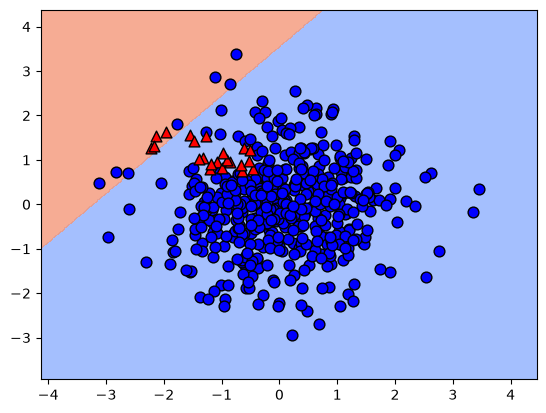

In [97]:
# Create binary classifier
lr_class_1 = LogisticRegression(max_iter=1000)
lr_class_1.fit(X_train, y_train == 1)

# Plot class 1 vs all other classes
plot_classifier(X_train, y_train == 1, clf = lr_class_1)

/tmp/ipykernel_19165/1518515497.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[0]], X1[y==labels[0]], cmap=plt.cm.coolwarm, s=60, c='b', marker='o', edgecolors='k')
/tmp/ipykernel_19165/1518515497.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[1]], X1[y==labels[1]], cmap=plt.cm.coolwarm, s=60, c='r', marker='^', edgecolors='k')


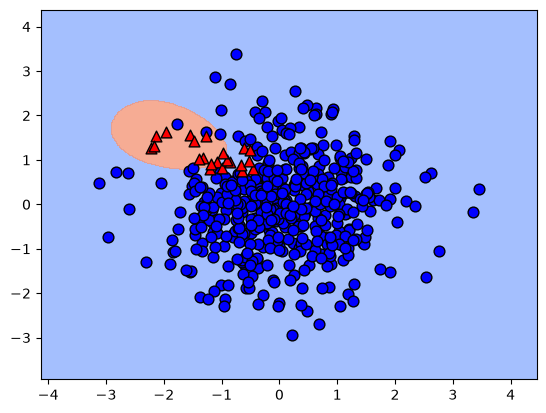

In [98]:
# One vs Rest SVM
from sklearn.svm import SVC

svm_class_1 = SVC()
svm_class_1.fit(X_train, y_train == 1)
plot_classifier(X_train, y_train == 1, clf = svm_class_1)

### Support Vector Machines

In [101]:
# Get wine dataset
from sklearn.datasets import load_wine
wine = load_wine()
X = wine.data
X_subset = X[:, :2]  
y = wine.target

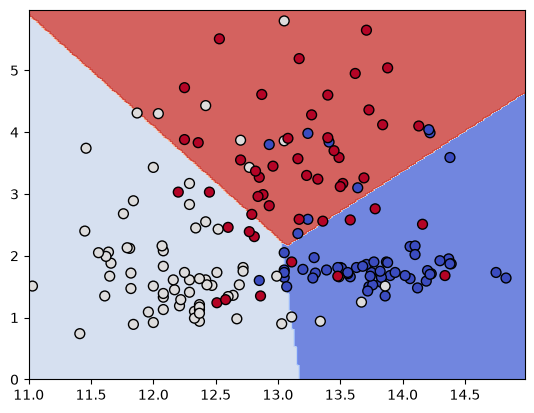

In [102]:
# Train a linear SVM
svm = SVC(kernel='linear')
svm.fit(X_subset, y)
plot_classifier(X_subset, y, clf = svm, lims=(11, 15, 0, 6))

In [106]:
# Make a new dataset keeping only support vectors
print("Number of support vectors:", len(svm.support_vectors_))
print("Number of original samples:", len(X_subset))

Number of support vectors: 81
Number of original samples: 178


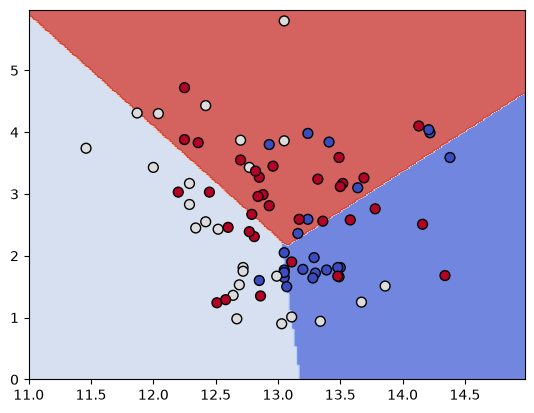

In [107]:
X_small = X_subset[svm.support_]
y_small = y[svm.support_]

svm_small = SVC(kernel='linear')
svm_small.fit(X_small, y_small)
plot_classifier(X_small, y_small, clf = svm_small, lims=(11, 15, 0, 6))

In [109]:
# get digits dataset
from sklearn.datasets import load_digits
digits = load_digits()

# Make a binary version of the digits dataset, predict whether the digit is a 2 or not
X = digits.data
y_raw = digits.target

y = (y_raw == 2).astype(int)  # Convert to binary labels: 1 if digit is 2, else 0

In [111]:
svm = SVC()

parameters = {'gamma': [0.001, 0.01, 0.1, 1]}
searcher = GridSearchCV(svm, parameters, cv=5)
searcher.fit(X, y)

print("Best parameters found: ", searcher.best_params_)

Best parameters found:  {'gamma': 0.001}


In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [115]:
# Instantiate an RBF SVM
svm = SVC()

# Instantiate the GridSearchCV object and run the search
parameters = {'C':[0.1, 1, 10], 'gamma':[0.00001, 0.0001, 0.001, 0.01, 0.1]}
searcher = GridSearchCV(svm, param_grid = parameters)
searcher.fit(X_train, y_train)

# Report the best parameters and the corresponding score
print("Best CV params", searcher.best_params_)
print("Best CV accuracy", searcher.best_score_)

# Report the test accuracy using these best parameters
print("Test accuracy of best grid search hypers:", searcher.score(X_test, y_test))

Best CV params {'C': 10, 'gamma': 0.0001}
Best CV accuracy 1.0
Test accuracy of best grid search hypers: 1.0


In [117]:
# SGDClassifier
from sklearn.linear_model import SGDClassifier

linear_classifier = SGDClassifier(random_state=42)

parameters = {'alpha':[0.00001, 0.0001, 0.001, 0.01, 0.1, 1], 
            'loss':["hinge", "log_loss"]}
searcher = GridSearchCV(linear_classifier, parameters, cv=10)
searcher.fit(X_train, y_train)

# Report the best parameters and the corresponding score
print("Best CV params", searcher.best_params_)
print("Best CV accuracy", searcher.best_score_)
print("Test accuracy of best grid search hypers:", searcher.score(X_test, y_test))

Best CV params {'alpha': 0.01, 'loss': 'hinge'}
Best CV accuracy 1.0
Test accuracy of best grid search hypers: 0.9933333333333333
